In [1]:
import pandas as pd
import numpy as np
import os, re
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
INPUT_FILE = '/Users/whd/Downloads/gdshyc/train4.xlsx'
TARGET_COL = 'η（mV)'
SELECTED_FEATS = ['Am', 'χ', 'Δχ', 'Ф']

# 1. Load Data
df = pd.read_excel(INPUT_FILE)
X = df[SELECTED_FEATS].copy()
y = df[TARGET_COL].copy()

# 2. Clean Feature Names
X.columns = [re.sub(r'\[|\]|<', '_', col) for col in X.columns]

# 3. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [2]:
# Configuration for Bayesian Search
search_spaces = {
    'RF': {
        'n_estimators': Integer(50, 300),      
        'max_depth': Integer(2, 5),            
        'min_samples_leaf': Integer(3, 6),     
        'max_features': Categorical(['sqrt', 'log2'])
    },
    'XGBR': {
        'n_estimators': Integer(50, 300),
        'max_depth': Integer(2, 4),            
        'learning_rate': Real(0.01, 0.1, prior='log-uniform'),
        'reg_alpha': Real(0.1, 10.0, prior='log-uniform'), 
        'reg_lambda': Real(0.5, 20.0, prior='log-uniform')
    },
    'GBRT': {
        'n_estimators': Integer(50, 300),      
        'learning_rate': Real(0.01, 0.1, prior='log-uniform'),
        'max_depth': Integer(2, 3),            
        'subsample': Real(0.6, 0.8)            
    }
}

inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)
best_estimators = {}
best_params_dict = {} 

print("Starting Bayesian Optimization on Training Set...")

base_models = {
    'RF': RandomForestRegressor(random_state=42),
    'XGBR': XGBRegressor(random_state=42, objective='reg:squarederror'),
    'GBRT': GradientBoostingRegressor(random_state=42)
}

for name, est in base_models.items():
    print(f"\nOptimizing {name}...")
    opt = BayesSearchCV(
        estimator=est,
        search_spaces=search_spaces[name],
        n_iter=25,
        cv=inner_cv,
        scoring='r2',
        n_jobs=-1,
        random_state=42
    )
    
    opt.fit(X_train, y_train)
    
    best_estimators[name] = opt.best_estimator_
    best_params_dict[name] = opt.best_params_
    
    print(f"{name} Best CV R2: {opt.best_score_:.4f}")
    print(f"{name} Optimal Hyperparameters:")
    for key, value in opt.best_params_.items():
        print(f"    {key}: {value}")

print("\nOptimization completed!")

Starting Bayesian Optimization on Training Set...

Optimizing RF...
RF Best CV R2: 0.4797
RF Optimal Hyperparameters:
    max_depth: 5
    max_features: sqrt
    min_samples_leaf: 6
    n_estimators: 112

Optimizing XGBR...
XGBR Best CV R2: 0.3137
XGBR Optimal Hyperparameters:
    learning_rate: 0.06200598858125372
    max_depth: 2
    n_estimators: 50
    reg_alpha: 0.1
    reg_lambda: 20.0

Optimizing GBRT...
GBRT Best CV R2: 0.3739
GBRT Optimal Hyperparameters:
    learning_rate: 0.01
    max_depth: 2
    n_estimators: 141
    subsample: 0.6424049948016604

Optimization completed!


Constructing Stacking Ensemble Model...

 Test Set Evaluation Results 
R² Score:  0.5684
MAE:       78.5808 mV
RMSE:      112.4672 mV


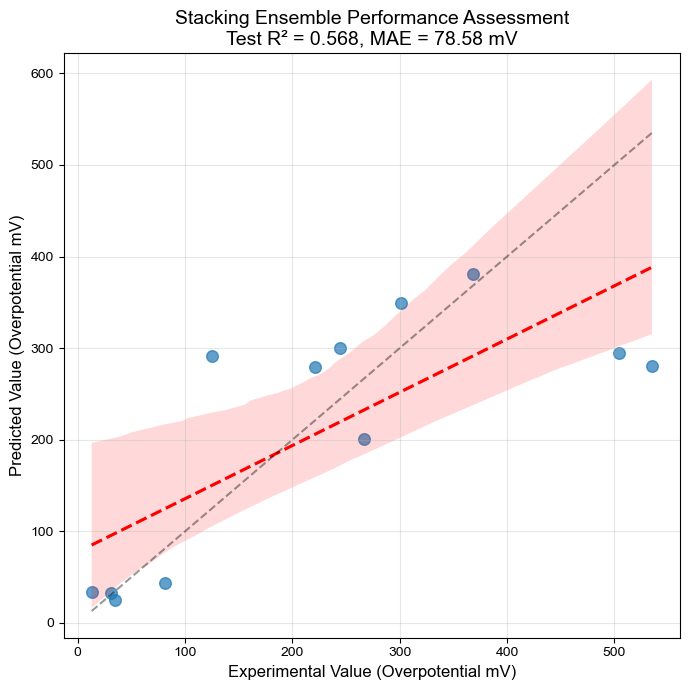

In [3]:
print("Constructing Stacking Ensemble Model...")

train_meta_features = []
test_meta_features = []

# Generate Meta-features 
for name, model in best_estimators.items():

    oof_pred = cross_val_predict(model, X_train, y_train, cv=5).reshape(-1, 1)
    train_meta_features.append(oof_pred)
    
    test_pred = model.predict(X_test).reshape(-1, 1)
    test_meta_features.append(test_pred)

# Stack meta-features horizontally
X_meta_train = np.hstack(train_meta_features)
X_meta_test = np.hstack(test_meta_features)

# Train Meta-learner
meta_learner = ElasticNetCV(cv=5, random_state=42)
meta_learner.fit(X_meta_train, y_train)

# Final Prediction
y_final_pred = meta_learner.predict(X_meta_test)

# Evaluation
r2 = r2_score(y_test, y_final_pred)
mae = mean_absolute_error(y_test, y_final_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_final_pred))

print(f"\n Test Set Evaluation Results ")
print(f"R² Score:  {r2:.4f}")
print(f"MAE:       {mae:.4f} mV")
print(f"RMSE:      {rmse:.4f} mV")

# Save results for future analysis
plot_data = pd.DataFrame({
    "True_Overpotential_mV": y_test.values,
    "Predicted_Overpotential_mV": y_final_pred,
    "Residual_mV": y_test.values - y_final_pred
})

save_path = "/Users/whd/Downloads/gdshyc/Stacking_Results_4_Feats.xlsx"
os.makedirs("/Users/whd/Downloads/gdshyc", exist_ok=True)
plot_data.to_excel(save_path, index=False, engine="openpyxl")


plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(7, 7))
sns.regplot(x=y_test, y=y_final_pred, scatter_kws={'s':70, 'alpha':0.7}, line_kws={'color':'red', 'ls':'--'})


plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', alpha=0.4)

plt.title(f'Stacking Ensemble Performance Assessment\nTest R² = {r2:.3f}, MAE = {mae:.2f} mV', fontsize=14)
plt.xlabel('Experimental Value (Overpotential mV)', fontsize=12)
plt.ylabel('Predicted Value (Overpotential mV)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# 5 features
INPUT_FILE = '/Users/whd/Downloads/gdshyc/train4.xlsx'
TARGET_COL = 'η（mV)'
SELECTED_FEATS = ['Am', 'χ', 'Δχ', 'Ф', 'OHBE']


df = pd.read_excel(INPUT_FILE)
X = df[SELECTED_FEATS].copy()
y = df[TARGET_COL].copy()
X.columns = [re.sub(r'\[|\]|<', '_', col) for col in X.columns]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [5]:
# Configuration for Bayesian Search Spaces
search_spaces = {
    'RF': {
        'n_estimators': Integer(50, 300),      
        'max_depth': Integer(2, 5),            
        'min_samples_leaf': Integer(3, 6),     
        'max_features': Categorical(['sqrt', 'log2'])
    },
    'XGBR': {
        'n_estimators': Integer(50, 300),
        'max_depth': Integer(2, 4),            
        'learning_rate': Real(0.01, 0.1, prior='log-uniform'),
        'reg_alpha': Real(0.1, 10.0, prior='log-uniform'), 
        'reg_lambda': Real(0.5, 20.0, prior='log-uniform')
    },
    'GBRT': {
        'n_estimators': Integer(50, 300),      
        'learning_rate': Real(0.01, 0.1, prior='log-uniform'),
        'max_depth': Integer(2, 3),            
        'subsample': Real(0.6, 0.8)            
    }
}

inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)
best_estimators = {}
best_params_dict = {}  

print("Starting Bayesian Optimization on Training Set...")

base_models = {
    'RF': RandomForestRegressor(random_state=42),
    'XGBR': XGBRegressor(random_state=42, objective='reg:squarederror'),
    'GBRT': GradientBoostingRegressor(random_state=42)
}

for name, est in base_models.items():
    print(f"\nOptimizing {name}...")
    opt = BayesSearchCV(
        estimator=est,
        search_spaces=search_spaces[name],
        n_iter=25,
        cv=inner_cv,
        scoring='r2',
        n_jobs=-1,
        random_state=42
    )

    opt.fit(X_train, y_train)
    
    best_estimators[name] = opt.best_estimator_
    best_params_dict[name] = opt.best_params_
    
    print(f"{name} Training Set 5-fold CV Mean R2: {opt.best_score_:.4f}")
    print(f"{name} Optimal Hyperparameters:")
    for key, value in opt.best_params_.items():
        print(f"    {key}: {value}")

print("\nOptimization completed!")

Starting Bayesian Optimization on Training Set...

Optimizing RF...
RF Training Set 5-fold CV Mean R2: 0.4714
RF Optimal Hyperparameters:
    max_depth: 2
    max_features: sqrt
    min_samples_leaf: 6
    n_estimators: 51

Optimizing XGBR...
XGBR Training Set 5-fold CV Mean R2: 0.3442
XGBR Optimal Hyperparameters:
    learning_rate: 0.04569283557510595
    max_depth: 2
    n_estimators: 50
    reg_alpha: 0.11212948446326344
    reg_lambda: 7.055397330008068

Optimizing GBRT...
GBRT Training Set 5-fold CV Mean R2: 0.3993
GBRT Optimal Hyperparameters:
    learning_rate: 0.01
    max_depth: 2
    n_estimators: 172
    subsample: 0.6

Optimization completed!


Constructing Stacking Ensemble Model...

 Test Set Evaluation Results
R² Score:  0.5820
MAE:       79.7374 mV
RMSE:      110.6812 mV


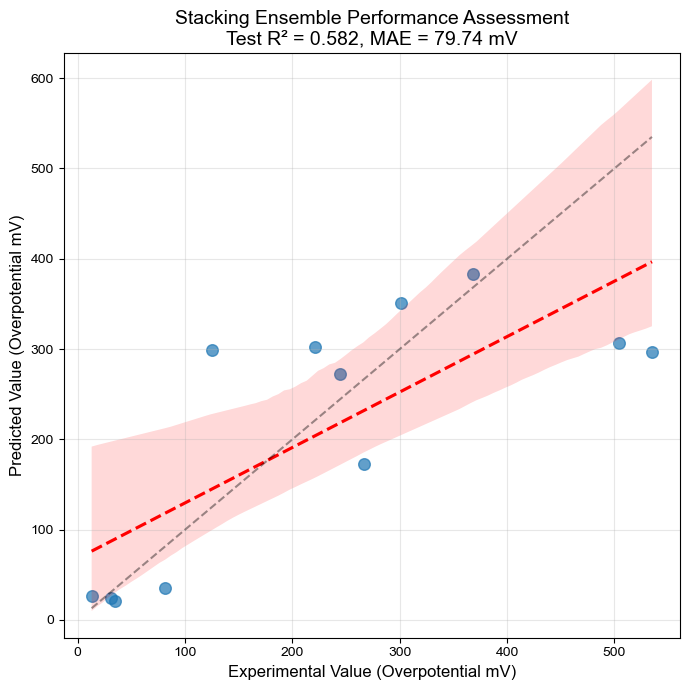

In [6]:
print("Constructing Stacking Ensemble Model...")

train_meta_features = []
test_meta_features = []

# Meta-feature Generation
for name, model in best_estimators.items():
    oof_pred = cross_val_predict(model, X_train, y_train, cv=5).reshape(-1, 1)
    train_meta_features.append(oof_pred)
    
    test_pred = model.predict(X_test).reshape(-1, 1)
    test_meta_features.append(test_pred)

# Consolidate meta-features via horizontal stacking
X_meta_train = np.hstack(train_meta_features)
X_meta_test = np.hstack(test_meta_features)

# Meta-learner Training
meta_learner = ElasticNetCV(cv=5, random_state=42)
meta_learner.fit(X_meta_train, y_train)

y_final_pred = meta_learner.predict(X_meta_test)

# Evaluation
r2 = r2_score(y_test, y_final_pred)
mae = mean_absolute_error(y_test, y_final_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_final_pred))

print(f"\n Test Set Evaluation Results")
print(f"R² Score:  {r2:.4f}")
print(f"MAE:       {mae:.4f} mV")
print(f"RMSE:      {rmse:.4f} mV")

# Data preparation for export
plot_data = pd.DataFrame({
    "Experimental_Overpotential_mV": y_test.values,
    "Predicted_Overpotential_mV": y_final_pred,
    "Residual_mV": y_test.values - y_final_pred
})

save_path = "/Users/whd/Downloads/gdshyc/Stacking_Test_Results_5_Feats.xlsx"
os.makedirs("/Users/whd/Downloads/gdshyc", exist_ok=True)
plot_data.to_excel(save_path, index=False, engine="openpyxl")


plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(7, 7))

sns.regplot(x=y_test, y=y_final_pred, scatter_kws={'s':70, 'alpha':0.7}, line_kws={'color':'red', 'ls':'--'})

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', alpha=0.4)

plt.title(f'Stacking Ensemble Performance Assessment\nTest R² = {r2:.3f}, MAE = {mae:.2f} mV', fontsize=14)
plt.xlabel('Experimental Value (Overpotential mV)', fontsize=12)
plt.ylabel('Predicted Value (Overpotential mV)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# 6 features
INPUT_FILE = '/Users/whd/Downloads/gdshyc/train4.xlsx'
TARGET_COL = 'η（mV)'
SELECTED_FEATS = ['Am', 'χ', 'Δχ', 'Ф', 'OHBE', 'Im']

df = pd.read_excel(INPUT_FILE)
X = df[SELECTED_FEATS].copy()
y = df[TARGET_COL].copy()
X.columns = [re.sub(r'\[|\]|<', '_', col) for col in X.columns]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [8]:
search_spaces = {
    'RF': {
        'n_estimators': Integer(50, 300),      
        'max_depth': Integer(2, 5),            
        'min_samples_leaf': Integer(3, 6),     
        'max_features': Categorical(['sqrt', 'log2'])
    },
    'XGBR': {
        'n_estimators': Integer(50, 300),
        'max_depth': Integer(2, 4),            
        'learning_rate': Real(0.01, 0.1, prior='log-uniform'),
        'reg_alpha': Real(0.1, 10.0, prior='log-uniform'), 
        'reg_lambda': Real(0.5, 20.0, prior='log-uniform')
    },
    'GBRT': {
        'n_estimators': Integer(50, 300),      
        'learning_rate': Real(0.01, 0.1, prior='log-uniform'),
        'max_depth': Integer(2, 3),            
        'subsample': Real(0.6, 0.8)            
    }
}

inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)
best_estimators = {}
best_params_dict = {}  

print("Starting Bayesian Optimization on training set...")

base_models = {
    'RF': RandomForestRegressor(random_state=42),
    'XGBR': XGBRegressor(random_state=42, objective='reg:squarederror'),
    'GBRT': GradientBoostingRegressor(random_state=42)
}

for name, est in base_models.items():
    print(f"\nOptimizing {name}...")
    opt = BayesSearchCV(
        estimator=est,
        search_spaces=search_spaces[name],
        n_iter=25,
        cv=inner_cv,
        scoring='r2',
        n_jobs=-1,
        random_state=42
    )
    
    opt.fit(X_train, y_train)
    
    best_estimators[name] = opt.best_estimator_
    best_params_dict[name] = opt.best_params_
    
    print(f"{name} training set 5-fold CV Mean R2: {opt.best_score_:.4f}")
    print(f"{name} optimal hyperparameters:")
    for key, value in opt.best_params_.items():
        print(f"    {key}: {value}")

print("\nOptimization completed!")

Starting Bayesian Optimization on training set...

Optimizing RF...
RF training set 5-fold CV Mean R2: 0.4945
RF optimal hyperparameters:
    max_depth: 3
    max_features: log2
    min_samples_leaf: 3
    n_estimators: 158

Optimizing XGBR...
XGBR training set 5-fold CV Mean R2: 0.2828
XGBR optimal hyperparameters:
    learning_rate: 0.01
    max_depth: 2
    n_estimators: 300
    reg_alpha: 10.0
    reg_lambda: 3.98771022481565

Optimizing GBRT...
GBRT training set 5-fold CV Mean R2: 0.4097
GBRT optimal hyperparameters:
    learning_rate: 0.012079626653125416
    max_depth: 2
    n_estimators: 177
    subsample: 0.6457737591634984

Optimization completed!


Constructing Stacking ensemble model...

 Test Set Evaluation Results
R² Score:  0.7161
MAE:       77.0328 mV
RMSE:      91.2207 mV


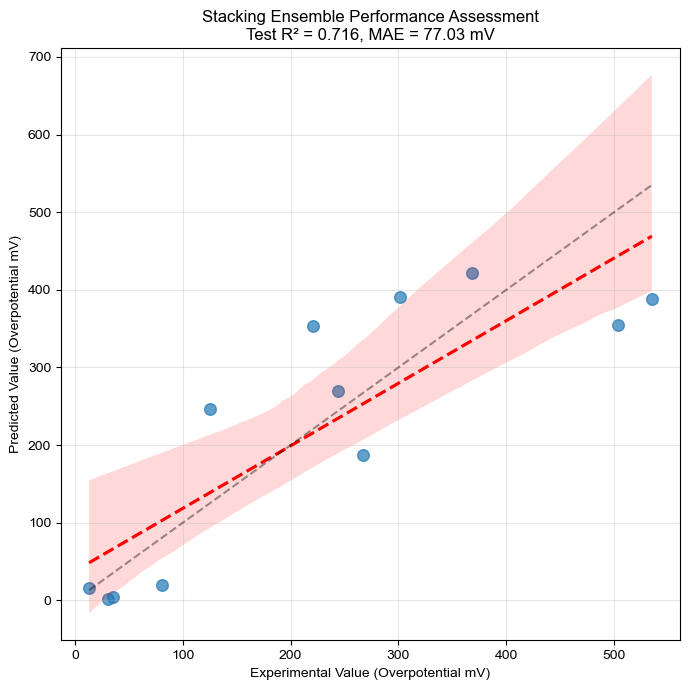

In [9]:
print("Constructing Stacking ensemble model...")

train_meta_features = []
test_meta_features = []

for name, model in best_estimators.items():
    oof_pred = cross_val_predict(model, X_train, y_train, cv=5).reshape(-1, 1)
    train_meta_features.append(oof_pred)
    
    test_pred = model.predict(X_test).reshape(-1, 1)
    test_meta_features.append(test_pred)

X_meta_train = np.hstack(train_meta_features)
X_meta_test = np.hstack(test_meta_features)

meta_learner = ElasticNetCV(cv=5, random_state=42)
meta_learner.fit(X_meta_train, y_train)

y_final_pred = meta_learner.predict(X_meta_test)

r2 = r2_score(y_test, y_final_pred)
mae = mean_absolute_error(y_test, y_final_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_final_pred))

print(f"\n Test Set Evaluation Results")
print(f"R² Score:  {r2:.4f}")
print(f"MAE:       {mae:.4f} mV")
print(f"RMSE:      {rmse:.4f} mV")

plot_data = pd.DataFrame({
    "Experimental_Value": y_test.values,
    "Predicted_Value": y_final_pred,
    "Residual": y_test.values - y_final_pred
})

save_path = "/Users/whd/Downloads/gdshyc/Stacking_Test_Results_6_Feats.xlsx"
os.makedirs("/Users/whd/Downloads/gdshyc", exist_ok=True)
plot_data.to_excel(save_path, index=False, engine="openpyxl")

plt.figure(figsize=(7, 7))
sns.regplot(x=y_test, y=y_final_pred, scatter_kws={'s':70, 'alpha':0.7}, line_kws={'color':'red', 'ls':'--'})
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', alpha=0.4)

plt.title(f'Stacking Ensemble Performance Assessment\nTest R² = {r2:.3f}, MAE = {mae:.2f} mV')
plt.xlabel('Experimental Value (Overpotential mV)')
plt.ylabel('Predicted Value (Overpotential mV)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# 7 features
INPUT_FILE = '/Users/whd/Downloads/gdshyc/train4.xlsx'
TARGET_COL = 'η（mV)'
SELECTED_FEATS = ['Am', 'χ', 'Δχ', 'Ф', 'OHBE', 'Im','ΔФ']

df = pd.read_excel(INPUT_FILE)
X = df[SELECTED_FEATS].copy()
y = df[TARGET_COL].copy()
X.columns = [re.sub(r'\[|\]|<', '_', col) for col in X.columns]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [11]:
search_spaces = {
    'RF': {
        'n_estimators': Integer(50, 300),      
        'max_depth': Integer(2, 5),            
        'min_samples_leaf': Integer(3, 6),     
        'max_features': Categorical(['sqrt', 'log2'])
    },
    'XGBR': {
        'n_estimators': Integer(50, 300),
        'max_depth': Integer(2, 4),            
        'learning_rate': Real(0.01, 0.1, prior='log-uniform'),
        'reg_alpha': Real(0.1, 10.0, prior='log-uniform'), 
        'reg_lambda': Real(0.5, 20.0, prior='log-uniform')
    },
    'GBRT': {
        'n_estimators': Integer(50, 300),      
        'learning_rate': Real(0.01, 0.1, prior='log-uniform'),
        'max_depth': Integer(2, 3),            
        'subsample': Real(0.6, 0.8)            
    }
}

inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)
best_estimators = {}
best_params_dict = {}  

print("Starting Bayesian Optimization on training set...")

base_models = {
    'RF': RandomForestRegressor(random_state=42),
    'XGBR': XGBRegressor(random_state=42, objective='reg:squarederror'),
    'GBRT': GradientBoostingRegressor(random_state=42)
}

for name, est in base_models.items():
    print(f"\nOptimizing {name}...")
    opt = BayesSearchCV(
        estimator=est,
        search_spaces=search_spaces[name],
        n_iter=25,
        cv=inner_cv,
        scoring='r2',
        n_jobs=-1,
        random_state=42
    )
    opt.fit(X_train, y_train)
    
    best_estimators[name] = opt.best_estimator_
    best_params_dict[name] = opt.best_params_
    
    print(f"{name} training set 5-fold CV Mean R2: {opt.best_score_:.4f}")
    print(f"{name} optimal hyperparameters:")
    for key, value in opt.best_params_.items():
        print(f"    {key}: {value}")

print("\nOptimization completed!")

Starting Bayesian Optimization on training set...

Optimizing RF...
RF training set 5-fold CV Mean R2: 0.4599
RF optimal hyperparameters:
    max_depth: 5
    max_features: log2
    min_samples_leaf: 4
    n_estimators: 123

Optimizing XGBR...
XGBR training set 5-fold CV Mean R2: 0.2683
XGBR optimal hyperparameters:
    learning_rate: 0.011199786636397214
    max_depth: 2
    n_estimators: 300
    reg_alpha: 10.0
    reg_lambda: 20.0

Optimizing GBRT...
GBRT training set 5-fold CV Mean R2: 0.3734
GBRT optimal hyperparameters:
    learning_rate: 0.01
    max_depth: 2
    n_estimators: 172
    subsample: 0.6439023042698048

Optimization completed!


Constructing Stacking ensemble model...

 Test Set Evaluation Results
R² Score:  0.5867
MAE:       80.6468 mV
RMSE:      110.0519 mV


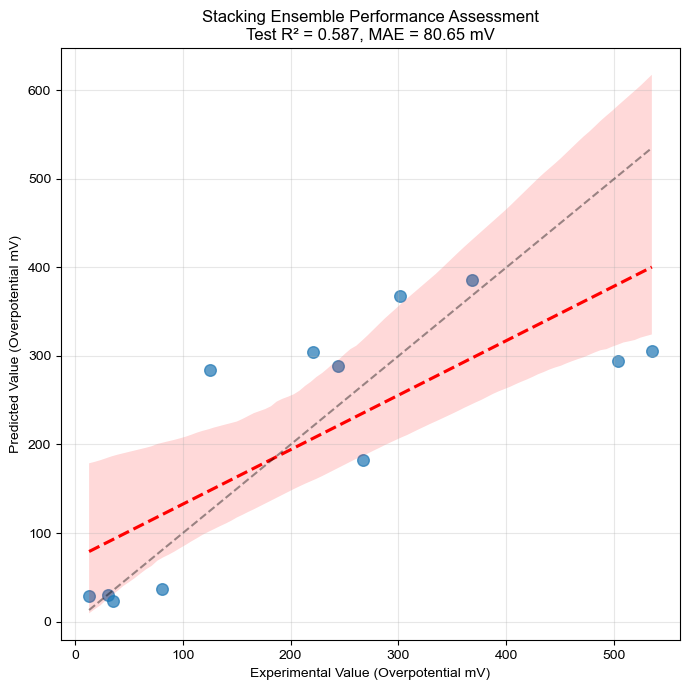

In [12]:
print("Constructing Stacking ensemble model...")

train_meta_features = []
test_meta_features = []

for name, model in best_estimators.items():
    oof_pred = cross_val_predict(model, X_train, y_train, cv=5).reshape(-1, 1)
    train_meta_features.append(oof_pred)
    
    model.fit(X_train, y_train)
    test_pred = model.predict(X_test).reshape(-1, 1)
    test_meta_features.append(test_pred)

X_meta_train = np.hstack(train_meta_features)
X_meta_test = np.hstack(test_meta_features)

meta_learner = ElasticNetCV(cv=5, random_state=42)
meta_learner.fit(X_meta_train, y_train)

y_final_pred = meta_learner.predict(X_meta_test)

r2 = r2_score(y_test, y_final_pred)
mae = mean_absolute_error(y_test, y_final_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_final_pred))

print(f"\n Test Set Evaluation Results")
print(f"R² Score:  {r2:.4f}")
print(f"MAE:       {mae:.4f} mV")
print(f"RMSE:      {rmse:.4f} mV")

plot_data = pd.DataFrame({
    "Experimental_Value": y_test.values,
    "Predicted_Value": y_final_pred,
    "Residual": y_test.values - y_final_pred
})

save_path = "/Users/whd/Downloads/gdshyc/Stacking_Test_Results_7_Feats.xlsx"
os.makedirs("/Users/whd/Downloads/gdshyc", exist_ok=True)
plot_data.to_excel(save_path, index=False, engine="openpyxl")

plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(7, 7))
sns.regplot(x=y_test, y=y_final_pred, scatter_kws={'s':70, 'alpha':0.7}, line_kws={'color':'red', 'ls':'--'})
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', alpha=0.4)

plt.title(f'Stacking Ensemble Performance Assessment\nTest R² = {r2:.3f}, MAE = {mae:.2f} mV')
plt.xlabel('Experimental Value (Overpotential mV)')
plt.ylabel('Predicted Value (Overpotential mV)')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [13]:
# 8 features
INPUT_FILE = '/Users/whd/Downloads/gdshyc/train4.xlsx'
TARGET_COL = 'η（mV)'
SELECTED_FEATS = ['Am', 'χ', 'Δχ', 'Ф', 'OHBE', 'Im','ΔФ','ΔHBE']

df = pd.read_excel(INPUT_FILE)
X = df[SELECTED_FEATS].copy()
y = df[TARGET_COL].copy()
X.columns = [re.sub(r'\[|\]|<', '_', col) for col in X.columns]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [14]:
search_spaces = {
    'RF': {
        'n_estimators': Integer(50, 300),      
        'max_depth': Integer(2, 5),            
        'min_samples_leaf': Integer(3, 6),     
        'max_features': Categorical(['sqrt', 'log2'])
    },
    'XGBR': {
        'n_estimators': Integer(50, 300),
        'max_depth': Integer(2, 4),            
        'learning_rate': Real(0.01, 0.1, prior='log-uniform'),
        'reg_alpha': Real(0.1, 10.0, prior='log-uniform'), 
        'reg_lambda': Real(0.5, 20.0, prior='log-uniform')
    },
    'GBRT': {
        'n_estimators': Integer(50, 300),      
        'learning_rate': Real(0.01, 0.1, prior='log-uniform'),
        'max_depth': Integer(2, 3),            
        'subsample': Real(0.6, 0.8)            
    }
}

inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)
best_estimators = {}
best_params_dict = {}  

print("Starting Bayesian Optimization on training set...")

base_models = {
    'RF': RandomForestRegressor(random_state=42),
    'XGBR': XGBRegressor(random_state=42, objective='reg:squarederror'),
    'GBRT': GradientBoostingRegressor(random_state=42)
}

for name, est in base_models.items():
    print(f"\nOptimizing {name}...")
    opt = BayesSearchCV(
        estimator=est,
        search_spaces=search_spaces[name],
        n_iter=25,
        cv=inner_cv,
        scoring='r2',
        n_jobs=-1,
        random_state=42
    )
    opt.fit(X_train, y_train)
    
    best_estimators[name] = opt.best_estimator_
    best_params_dict[name] = opt.best_params_
    
    print(f"{name} training set 5-fold CV Mean R2: {opt.best_score_:.4f}")
    print(f"{name} optimal hyperparameters:")
    for key, value in opt.best_params_.items():
        print(f"    {key}: {value}")

print("\nOptimization completed!")

Starting Bayesian Optimization on training set...

Optimizing RF...
RF training set 5-fold CV Mean R2: 0.4421
RF optimal hyperparameters:
    max_depth: 4
    max_features: log2
    min_samples_leaf: 6
    n_estimators: 95

Optimizing XGBR...
XGBR training set 5-fold CV Mean R2: 0.2942
XGBR optimal hyperparameters:
    learning_rate: 0.01
    max_depth: 2
    n_estimators: 144
    reg_alpha: 0.5989377086987546
    reg_lambda: 0.8122722933313976

Optimizing GBRT...
GBRT training set 5-fold CV Mean R2: 0.3461
GBRT optimal hyperparameters:
    learning_rate: 0.01
    max_depth: 2
    n_estimators: 205
    subsample: 0.6337369848800631

Optimization completed!


Constructing Stacking ensemble model...

 Test Set Evaluation Results 
R² Score:  0.5926
MAE:       82.7683 mV
RMSE:      109.2646 mV


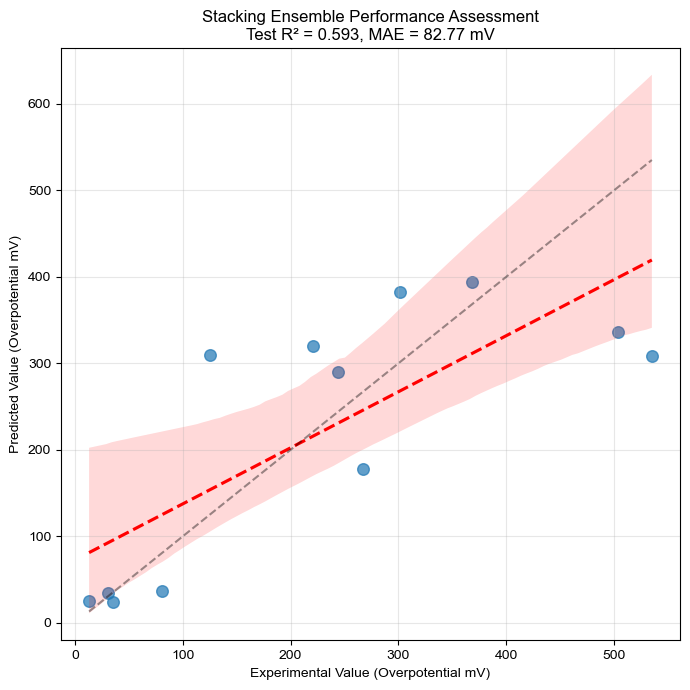

In [15]:
print("Constructing Stacking ensemble model...")

train_meta_features = []
test_meta_features = []

for name, model in best_estimators.items():
    oof_pred = cross_val_predict(model, X_train, y_train, cv=5).reshape(-1, 1)
    train_meta_features.append(oof_pred)
    
    test_pred = model.predict(X_test).reshape(-1, 1)
    test_meta_features.append(test_pred)

X_meta_train = np.hstack(train_meta_features)
X_meta_test = np.hstack(test_meta_features)

meta_learner = ElasticNetCV(cv=5, random_state=42)
meta_learner.fit(X_meta_train, y_train)

y_final_pred = meta_learner.predict(X_meta_test)

r2 = r2_score(y_test, y_final_pred)
mae = mean_absolute_error(y_test, y_final_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_final_pred))

print(f"\n Test Set Evaluation Results ")
print(f"R² Score:  {r2:.4f}")
print(f"MAE:       {mae:.4f} mV")
print(f"RMSE:      {rmse:.4f} mV")

plot_data = pd.DataFrame({
    "Experimental_Value": y_test.values,
    "Predicted_Value": y_final_pred,
    "Residual": y_test.values - y_final_pred
})

save_path = "/Users/whd/Downloads/gdshyc/Stacking_Test_Results_8_Feats.xlsx"
os.makedirs("/Users/whd/Downloads/gdshyc", exist_ok=True)
plot_data.to_excel(save_path, index=False, engine="openpyxl")

plt.figure(figsize=(7, 7))
sns.regplot(x=y_test, y=y_final_pred, scatter_kws={'s':70, 'alpha':0.7}, line_kws={'color':'red', 'ls':'--'})
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', alpha=0.4)

plt.title(f'Stacking Ensemble Performance Assessment\nTest R² = {r2:.3f}, MAE = {mae:.2f} mV')
plt.xlabel('Experimental Value (Overpotential mV)')
plt.ylabel('Predicted Value (Overpotential mV)')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()